In [ ]:
#import the libraries
import os, random
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from PIL import Image
import torchvision.transforms as T
import torchvision.models as models


In [ ]:
#Reproducibility
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
device


'cuda'

In [ ]:
#Define dataset root and check files exist
from pathlib import Path

DATA_ROOT = Path(r"C:\Users\aggel\OneDrive\Υπολογιστής\DATA FUSION\MATWI\MATWI")

labels_path = DATA_ROOT / "labels.csv"
sets_path   = DATA_ROOT / "sets.csv"

# Stop immediately if something is wrong
assert labels_path.exists(), f"labels.csv not found: {labels_path}"
assert sets_path.exists(), f"sets.csv not found: {sets_path}"

print("OK:", labels_path)
print("OK:", sets_path)


OK: C:\Users\aggel\OneDrive\Υπολογιστής\DATA FUSION\MATWI\MATWI\labels.csv
OK: C:\Users\aggel\OneDrive\Υπολογιστής\DATA FUSION\MATWI\MATWI\sets.csv


In [ ]:
# Load labels.csv
df = pd.read_csv(labels_path)

def resolve_path(p: str) -> Path:
    p = Path(str(p))
    # labels.csv usually stores paths like "MATWI/Set1/images/....jpg"
    if len(p.parts) > 0 and p.parts[0].lower() == "matwi":
        return DATA_ROOT / Path(*p.parts[1:])
    return DATA_ROOT / p

df.head()


,ImageName,SensorName,Set,ImageID,SensorID,wear,type,ImageDateTime,SensorDateTime,ImageFile,SensorFile
0,File_name_2022-09-09T13_42_21.698185.jpg,File_name_2022-09-09T13_30_37.534347.csv,1,0.0,0.0,30.0,flank_wear,2022-09-09 13:42:21.698185,2022-09-09 13:30:37.534347,MATWI/Set1/images/File_name_2022-09-09T13_42_2...,MATWI/Set1/sensordata/File_name_2022-09-09T13_...
1,File_name_2022-09-09T13_57_28.118460.jpg,File_name_2022-09-09T13_42_22.323924.csv,1,1.0,1.0,30.0,flank_wear,2022-09-09 13:57:28.118460,2022-09-09 13:42:22.323924,MATWI/Set1/images/File_name_2022-09-09T13_57_2...,MATWI/Set1/sensordata/File_name_2022-09-09T13_...
2,File_name_2022-09-09T14_02_11.912597.jpg,File_name_2022-09-09T13_57_28.734803.csv,1,2.0,2.0,60.0,adhesion,2022-09-09 14:02:11.912597,2022-09-09 13:57:28.734803,MATWI/Set1/images/File_name_2022-09-09T14_02_1...,MATWI/Set1/sensordata/File_name_2022-09-09T13_...
3,File_name_2022-09-09T14_06_06.154768.jpg,File_name_2022-09-09T14_02_12.498379.csv,1,3.0,3.0,90.0,adhesion,2022-09-09 14:06:06.154768,2022-09-09 14:02:12.498379,MATWI/Set1/images/File_name_2022-09-09T14_06_0...,MATWI/Set1/sensordata/File_name_2022-09-09T14_...
4,File_name_2022-09-09T14_15_05.378030.jpg,File_name_2022-09-09T14_06_06.752937.csv,1,4.0,4.0,30.0,flank_wear,2022-09-09 14:15:05.378030,2022-09-09 14:06:06.752937,MATWI/Set1/images/File_name_2022-09-09T14_15_0...,MATWI/Set1/sensordata/File_name_2022-09-09T14_...


In [ ]:
# Keep rows with an image + wear + set
df = df.dropna(subset=["ImageFile", "wear", "Set"]).copy()
df["Set"] = df["Set"].astype(int)
df["wear"] = df["wear"].astype(float)

# Convert micrometers to millimeters (paper uses mm, also nicer numeric scale)
df["y"] = df["wear"] / 1000.0

# Drop rows where image file doesn't exist (sync/path issues)
df["img_path"] = df["ImageFile"].apply(resolve_path)
df = df[df["img_path"].apply(lambda p: p.exists())].reset_index(drop=True)

print("Total usable image samples:", len(df))
display(df["Set"].value_counts().sort_index())


Total usable image samples: 1663


Set
1      92
2      97
3     103
4      99
5      65
6     148
7     105
8     102
9     102
10    102
11    101
12     50
13     53
14    148
15     50
16     99
17    147
Name: count, dtype: int64

In [ ]:
#Train/val/test split by SET
train_sets = [1,2,5,7,8,10,11]
val_sets   = [3,6,12]
test_sets  = [4,9,13]

train_df = df[df["Set"].isin(train_sets)].reset_index(drop=True)
val_df   = df[df["Set"].isin(val_sets)].reset_index(drop=True)
test_df  = df[df["Set"].isin(test_sets)].reset_index(drop=True)

print("Train:", len(train_df), " Val:", len(val_df), " Test:", len(test_df))
print("Train set counts:", train_df["Set"].value_counts().sort_index().to_dict())
print("Val set counts:  ", val_df["Set"].value_counts().sort_index().to_dict())
print("Test set counts: ", test_df["Set"].value_counts().sort_index().to_dict())


Train: 664  Val: 301  Test: 254
Train set counts: {1: 92, 2: 97, 5: 65, 7: 105, 8: 102, 10: 102, 11: 101}
Val set counts:   {3: 103, 6: 148, 12: 50}
Test set counts:  {4: 99, 9: 102, 13: 53}


In [ ]:
#crop
sets_df = pd.read_csv(sets_path)

def parse_crop(crop_str):
    # returns (x, y, w, h)
    x1, y1, a, b = [int(v.strip()) for v in str(crop_str).split(",")]
    # treat as x1,y1,x2,y2 if it looks like end coordinates
    if a > x1 and b > y1 and (a - x1) > 50 and (b - y1) > 50:
        x2, y2 = a, b
        w, h = x2 - x1, y2 - y1
    else:
        w, h = a, b
    return x1, y1, w, h

crop_map = {}
for _, row in sets_df.iterrows():
    set_name = str(row["Unnamed: 0"]).strip()  # "Set 1"
    set_id = int(set_name.split()[-1])
    crop_map[set_id] = parse_crop(row["crop"])

print("Example crop Set 1:", crop_map.get(1))


Example crop Set 1: (2470, 1000, 600, 400)


In [ ]:
#augmentation
img_tf_train = T.Compose([
    T.Resize((224, 224)),
    T.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])])

#Val/Test with no augmentation
img_tf_eval = T.Compose([
    T.Resize((224, 224)),
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])])


In [9]:
class MATWIImageDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform):
        self.df = df
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["img_path"]  # already resolved Path
        y = torch.tensor(row["y"], dtype=torch.float32)

        img = Image.open(img_path).convert("RGB")
        img = self.transform(img)
        return img, y


In [ ]:
 #Dataset with image and crop per set
class MATWIImageDatasetCropped(Dataset):
    def __init__(self, df: pd.DataFrame, transform, crop_map: dict):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.crop_map = crop_map

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["img_path"]
        set_id = int(row["Set"])
        y = torch.tensor(row["y"], dtype=torch.float32)

        img = Image.open(img_path).convert("RGB") #load image

        # crop using set-specific crop box
        if set_id in self.crop_map:
            x, y0, w, h = self.crop_map[set_id]
            img = img.crop((x, y0, x + w, y0 + h))

        img = self.transform(img)
        return img, y


In [ ]:
#dataloaders
train_loader = DataLoader(MATWIImageDatasetCropped(train_df, img_tf_train, crop_map),
                          batch_size=16, shuffle=True, num_workers=0, pin_memory=True)

val_loader   = DataLoader(MATWIImageDatasetCropped(val_df, img_tf_eval, crop_map),
                          batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

test_loader  = DataLoader(MATWIImageDatasetCropped(test_df, img_tf_eval, crop_map),
                          batch_size=32, shuffle=False, num_workers=0, pin_memory=True)

next(iter(train_loader))[0].shape



torch.Size([16, 3, 224, 224])

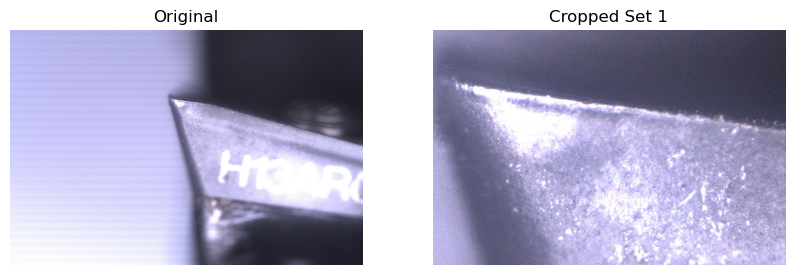

In [12]:
import matplotlib.pyplot as plt
set_id = 1
row = train_df[train_df["Set"] == set_id].iloc[0]
img = Image.open(row["img_path"]).convert("RGB")

x, y0, w, h = crop_map[set_id]
cropped = img.crop((x, y0, x+w, y0+h))

plt.figure(figsize=(10,4))
plt.subplot(1,2,1); plt.imshow(img); plt.title("Original"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(cropped); plt.title(f"Cropped Set {set_id}"); plt.axis("off")
plt.show()


In [ ]:
#model ResNet50 with regression head
class ResNet50Regressor(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        weights = models.ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        m = models.resnet50(weights=weights)
        
        # Replace classification head with regression head
        in_f = m.fc.in_features
        m.fc = nn.Linear(in_f, 1)  # regression output
        self.model = m

    def forward(self, x):
        return self.model(x).squeeze(1)

model = ResNet50Regressor(pretrained=True).to(device)
model


ResNet50Regressor(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
  

In [ ]:
import math
import torch
#Training  and evaluation loops
def train_epoch(model, loader, opt, device):
    model.train()
    total_sse, total_abs, n = 0.0, 0.0, 0

    for img, y in loader:          #  image-only loader returns (img, y)
        img = img.to(device)
        y = y.to(device)

        pred = model(img)          #  image-only model takes only img
        diff = pred - y

        total_sse += (diff ** 2).sum().item()
        total_abs += diff.abs().sum().item()
        n += y.numel()

        loss = (diff ** 2).mean()  # MSE
        opt.zero_grad()
        loss.backward()
        opt.step()

    mse = total_sse / n
    rmse = math.sqrt(mse)
    mae = total_abs / n
    return mse, mae, rmse


@torch.no_grad()
def eval_epoch(model, loader, device):
    model.eval()
    total_sse, total_abs, n = 0.0, 0.0, 0

    for img, y in loader:          #  image-only loader returns (img, y)
        img = img.to(device)
        y = y.to(device)

        pred = model(img)
        diff = pred - y

        total_sse += (diff ** 2).sum().item()
        total_abs += diff.abs().sum().item()
        n += y.numel()

    mse = total_sse / n
    rmse = math.sqrt(mse)
    mae = total_abs / n
    return mse, mae, rmse

In [ ]:
#Fit with early stopping
def fit_with_early_stopping(model, opt, best_path, tag, EPOCHS=50, patience=5, min_delta=1e-6):
    best_val_mae = 1e9
    bad_epochs = 0

    for epoch in range(1, EPOCHS + 1):
        tr_mse, tr_mae, tr_rmse = train_epoch(model, train_loader, opt, device)
        va_mse, va_mae, va_rmse = eval_epoch(model, val_loader, device)

        print(
            f"[{tag}] Epoch {epoch:02d} | "
            f"train MAE {tr_mae:.4f} mm RMSE {tr_rmse:.4f} mm | "
            f"val MAE {va_mae:.4f} mm RMSE {va_rmse:.4f} mm"
        )

        # keep early stopping based on val MAE (same behavior as before)
        if va_mae < best_val_mae - min_delta:
            best_val_mae = va_mae
            bad_epochs = 0
            torch.save(model.state_dict(), best_path)
            print(f"saved best (val MAE {best_val_mae:.4f} mm)")
        else:
            bad_epochs += 1
            print(f"  no improvement ({bad_epochs}/{patience})")
            if bad_epochs >= patience:
                print(f"Early stopping at epoch {epoch}. Best val MAE: {best_val_mae:.4f} mm")
                break

    model.load_state_dict(torch.load(best_path, map_location=device))
    te_mse, te_mae, te_rmse = eval_epoch(model, test_loader, device)
    print(
        f"[{tag}] TEST | "
        f"MAE {te_mae:.4f} mm ({te_mae*1000:.1f} µm) | "
        f"RMSE {te_rmse:.4f} mm ({te_rmse*1000:.1f} µm)"
    )

    return te_mae, te_rmse

In [ ]:
#transfer learning
model_tl = ResNet50Regressor(pretrained=True).to(device)

# freeze everything
for p in model_tl.model.parameters():
    p.requires_grad = False

# train only fc
for p in model_tl.model.fc.parameters():
    p.requires_grad = True

opt_tl = torch.optim.Adam(model_tl.model.fc.parameters(), lr=1e-3, weight_decay=1e-4)
best_path_tl = DATA_ROOT / "best_resnet50_transfer_fc.pt"

te_mae_tl, te_rmse_tl = fit_with_early_stopping(model_tl, opt_tl, best_path_tl, tag="ResNet50-TL(fc)", EPOCHS=20, patience=5)


[ResNet50-TL(fc)] Epoch 01 | train MAE 0.0882 mm RMSE 0.1131 mm | val MAE 0.0772 mm RMSE 0.0982 mm
saved best (val MAE 0.0772 mm)
[ResNet50-TL(fc)] Epoch 02 | train MAE 0.0656 mm RMSE 0.0850 mm | val MAE 0.0742 mm RMSE 0.0959 mm
saved best (val MAE 0.0742 mm)
[ResNet50-TL(fc)] Epoch 03 | train MAE 0.0619 mm RMSE 0.0820 mm | val MAE 0.0678 mm RMSE 0.0846 mm
saved best (val MAE 0.0678 mm)
[ResNet50-TL(fc)] Epoch 04 | train MAE 0.0545 mm RMSE 0.0702 mm | val MAE 0.0616 mm RMSE 0.0778 mm
saved best (val MAE 0.0616 mm)
[ResNet50-TL(fc)] Epoch 05 | train MAE 0.0524 mm RMSE 0.0668 mm | val MAE 0.0592 mm RMSE 0.0759 mm
saved best (val MAE 0.0592 mm)
[ResNet50-TL(fc)] Epoch 06 | train MAE 0.0506 mm RMSE 0.0676 mm | val MAE 0.0609 mm RMSE 0.0790 mm
  no improvement (1/5)
[ResNet50-TL(fc)] Epoch 07 | train MAE 0.0489 mm RMSE 0.0636 mm | val MAE 0.0598 mm RMSE 0.0755 mm
  no improvement (2/5)
[ResNet50-TL(fc)] Epoch 08 | train MAE 0.0463 mm RMSE 0.0603 mm | val MAE 0.0557 mm RMSE 0.0721 mm
saved b

C:\Users\aggel\AppData\Local\Temp\ipykernel_27780\2921671410.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=de

[ResNet50-TL(fc)] TEST | MAE 0.0548 mm (54.8 µm) | RMSE 0.0665 mm (66.5 µm)


In [ ]:
#Fine-tune layer4
model_ft = ResNet50Regressor(pretrained=True).to(device)

# freeze everything
for p in model_ft.model.parameters():
    p.requires_grad = False

# unfreeze layer4 + fc
for p in model_ft.model.layer4.parameters():
    p.requires_grad = True
for p in model_ft.model.fc.parameters():
    p.requires_grad = True

opt_ft = torch.optim.Adam(
    list(model_ft.model.layer4.parameters()) + list(model_ft.model.fc.parameters()),
    lr=1e-4, weight_decay=1e-4
)
best_path_ft = DATA_ROOT / "best_resnet50_finetune_layer4.pt"

te_mae_ft, te_rmse_ft = fit_with_early_stopping(model_ft, opt_ft, best_path_ft, tag="ResNet50-FT(layer4)", EPOCHS=20, patience=5)


[ResNet50-FT(layer4)] Epoch 01 | train MAE 0.0803 mm RMSE 0.1096 mm | val MAE 0.0866 mm RMSE 0.1116 mm
saved best (val MAE 0.0866 mm)
[ResNet50-FT(layer4)] Epoch 02 | train MAE 0.0552 mm RMSE 0.0714 mm | val MAE 0.0775 mm RMSE 0.1017 mm
saved best (val MAE 0.0775 mm)
[ResNet50-FT(layer4)] Epoch 03 | train MAE 0.0461 mm RMSE 0.0620 mm | val MAE 0.0622 mm RMSE 0.0805 mm
saved best (val MAE 0.0622 mm)
[ResNet50-FT(layer4)] Epoch 04 | train MAE 0.0384 mm RMSE 0.0491 mm | val MAE 0.0578 mm RMSE 0.0762 mm
saved best (val MAE 0.0578 mm)
[ResNet50-FT(layer4)] Epoch 05 | train MAE 0.0370 mm RMSE 0.0496 mm | val MAE 0.0553 mm RMSE 0.0758 mm
saved best (val MAE 0.0553 mm)
[ResNet50-FT(layer4)] Epoch 06 | train MAE 0.0325 mm RMSE 0.0428 mm | val MAE 0.0539 mm RMSE 0.0745 mm
saved best (val MAE 0.0539 mm)
[ResNet50-FT(layer4)] Epoch 07 | train MAE 0.0322 mm RMSE 0.0416 mm | val MAE 0.0539 mm RMSE 0.0745 mm
  no improvement (1/5)
[ResNet50-FT(layer4)] Epoch 08 | train MAE 0.0301 mm RMSE 0.0387 mm | 

C:\Users\aggel\AppData\Local\Temp\ipykernel_27780\2921671410.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=de

[ResNet50-FT(layer4)] TEST | MAE 0.0355 mm (35.5 µm) | RMSE 0.0460 mm (46.0 µm)


In [ ]:
#full fine tuning
model_full = ResNet50Regressor(pretrained=True).to(device)

#  everything trainable so full fine-tuning
opt_full = torch.optim.Adam(model_full.parameters(), lr=3e-4, weight_decay=1e-4)
best_path_full = DATA_ROOT / "best_resnet50_full.pt"

te_mae_full, te_rmse_full = fit_with_early_stopping(model_full, opt_full, best_path_full, tag="ResNet50-FULL", EPOCHS=20, patience=5)


[ResNet50-FULL] Epoch 01 | train MAE 0.0606 mm RMSE 0.0872 mm | val MAE 0.0571 mm RMSE 0.0833 mm
saved best (val MAE 0.0571 mm)
[ResNet50-FULL] Epoch 02 | train MAE 0.0400 mm RMSE 0.0516 mm | val MAE 0.0464 mm RMSE 0.0677 mm
saved best (val MAE 0.0464 mm)
[ResNet50-FULL] Epoch 03 | train MAE 0.0303 mm RMSE 0.0411 mm | val MAE 0.0472 mm RMSE 0.0629 mm
  no improvement (1/5)
[ResNet50-FULL] Epoch 04 | train MAE 0.0297 mm RMSE 0.0408 mm | val MAE 0.0435 mm RMSE 0.0627 mm
saved best (val MAE 0.0435 mm)
[ResNet50-FULL] Epoch 05 | train MAE 0.0241 mm RMSE 0.0407 mm | val MAE 0.0433 mm RMSE 0.0683 mm
saved best (val MAE 0.0433 mm)
[ResNet50-FULL] Epoch 06 | train MAE 0.0176 mm RMSE 0.0257 mm | val MAE 0.0446 mm RMSE 0.0725 mm
  no improvement (1/5)
[ResNet50-FULL] Epoch 07 | train MAE 0.0182 mm RMSE 0.0303 mm | val MAE 0.0432 mm RMSE 0.0740 mm
saved best (val MAE 0.0432 mm)
[ResNet50-FULL] Epoch 08 | train MAE 0.0179 mm RMSE 0.0345 mm | val MAE 0.0637 mm RMSE 0.0852 mm
  no improvement (1/5)


C:\Users\aggel\AppData\Local\Temp\ipykernel_27780\2921671410.py:28: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_path, map_location=de

[ResNet50-FULL] TEST | MAE 0.0240 mm (24.0 µm) | RMSE 0.0323 mm (32.3 µm)


In [19]:
print("ResNet50 Strategies (image-only)")
print(f"Transfer learning (fc only)      TEST MAE: {te_mae_tl*1000:.1f} µm | RMSE: {te_rmse_tl*1000:.1f} µm")
print(f"Fine-tuning (layer4 + fc)        TEST MAE: {te_mae_ft*1000:.1f} µm | RMSE: {te_rmse_ft*1000:.1f} µm")
print(f"Full fine-tuning (all layers)    TEST MAE: {te_mae_full*1000:.1f} µm | RMSE: {te_rmse_full*1000:.1f} µm")

ResNet50 Strategies (image-only)
Transfer learning (fc only)      TEST MAE: 54.8 µm | RMSE: 66.5 µm
Fine-tuning (layer4 + fc)        TEST MAE: 35.5 µm | RMSE: 46.0 µm
Full fine-tuning (all layers)    TEST MAE: 24.0 µm | RMSE: 32.3 µm
